In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc
# Add these imports at the top if not already present
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings('ignore')

In [3]:
# =============================================================================
# LOAD DATA - MULTI-CLASS VERSION
# =============================================================================

# Load the ML-ready dataset with multi-class labels
df = pd.read_csv('ml_ready_with_features_Multiclass.csv', sep=';')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

# Check available target columns
print("\n" + "="*70)
print("AVAILABLE TARGET OPTIONS")
print("="*70)
print("\n1. popularity_score   → Regression (continuous)")
print("2. popularity_label   → Binary (2 classes)")
print("3. popularity_3class  → 3-Class (Low/Medium/High)")
print("4. popularity_class   → 4-Class (Not Popular/Moderate/Popular/Very Popular)")
print("5. popularity_tier    → 4-Tier (Unpopular/Moderate/Popular/Mega Hit)")

# Check which columns exist
if 'popularity_class' in df.columns:
    print("\n✓ Multi-class labels found!")
else:
    print("\n⚠️  Multi-class labels NOT found. Please run 6_label_data_3.ipynb first!")

print("="*70)
df.head()

Dataset shape: (9161, 22)

Column names:
['id', 'Title', 'Artists', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', '# of Nationality', 'Loudness_norm', 'best_rank', 'weeks_on_chart', 'peak_score', 'longevity_score', 'popularity_score', 'popularity_label', 'popularity_class', 'popularity_tier', 'popularity_3class']

AVAILABLE TARGET OPTIONS

1. popularity_score   → Regression (continuous)
2. popularity_label   → Binary (2 classes)
3. popularity_3class  → 3-Class (Low/Medium/High)
4. popularity_class   → 4-Class (Not Popular/Moderate/Popular/Very Popular)
5. popularity_tier    → 4-Tier (Unpopular/Moderate/Popular/Mega Hit)

✓ Multi-class labels found!


,id,Title,Artists,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,...,Loudness_norm,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score,popularity_label,popularity_class,popularity_tier,popularity_3class
0,000xQL6tZNLJzIrtIgxqSl,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,0.748,0.627,-6.029,0.064,0.131,0.0,0.524,...,0.825120,40,118,80.5,100.0,80.25,Popular,Very Popular,Mega Hit,High
1,003VDDA7J3Xb2ZFlNx7nIZ,YELL OH,"Trippie Redd, Young Thug",0.842,0.578,-6.050,0.138,0.004,0.0,0.190,...,0.824511,108,2,46.5,10.0,27.25,Not Popular,Moderate,Unpopular,Low
2,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,0.353,0.755,-6.276,0.733,0.082,0.0,0.437,...,0.817955,91,14,55.0,70.0,55.50,Not Popular,Popular,Moderate,Medium
3,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,0.352,0.911,-5.230,0.075,0.001,0.0,0.236,...,0.848296,73,560,64.0,100.0,72.00,Popular,Popular,Popular,High
4,00B7TZ0Xawar6NZ00JFomN,Best Life (feat. Chance The Rapper),Cardi B,0.620,0.625,-7.438,0.553,0.287,0.0,0.665,...,0.784249,61,14,70.0,70.0,63.00,Not Popular,Popular,Popular,Medium


In [3]:
# Set pandas display options to show full output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Check for missing values
print("Missing values:")
print(df.isnull().sum())


# Basic statistics
print(f"\nFeature statistics:")
df.describe()

Missing values:
id                  0
Title               0
Artists             0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Valence             0
# of Artist         0
# of Nationality    0
Loudness_norm       0
best_rank           0
weeks_on_chart      0
peak_score          0
longevity_score     0
popularity_score    0
popularity_label    0
dtype: int64

Feature statistics:


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,Loudness_norm,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score
count,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.00000,9161.000000,9161.000000
mean,0.674146,0.636076,-6.465501,0.128299,0.234024,0.013770,0.486465,0.812458,87.258160,50.983626,56.87092,51.429975,49.007450
std,0.147904,0.170402,2.641113,0.117881,0.248563,0.082544,0.226281,0.076610,58.544799,120.342609,29.27240,41.295436,28.067511
min,0.073000,0.005000,-34.475000,0.022000,0.000000,0.000000,0.026000,0.000000,1.000000,1.000000,0.50000,5.000000,2.250000
25%,0.581000,0.532000,-7.638000,0.044000,0.040000,0.000000,0.310000,0.778448,35.000000,2.000000,33.00000,10.000000,23.000000
50%,0.691000,0.651000,-6.063000,0.076000,0.139000,0.000000,0.482000,0.824133,81.000000,8.000000,60.00000,40.000000,49.750000
75%,0.782000,0.761000,-4.731000,0.180000,0.351000,0.000000,0.660000,0.862770,135.000000,44.000000,83.00000,100.000000,75.750000
max,0.985000,0.996000,0.000000,0.966000,0.994000,0.956000,0.982000,1.000000,200.000000,2251.000000,100.00000,100.000000,90.000000



MULTI-CLASS TARGET SELECTION

📌 Selected target: popularity_class

LABEL DISTRIBUTION - POPULARITY_CLASS

Counts:
  Moderate       : 2,279 (24.88%)
  Not Popular    : 2,284 (24.93%)
  Popular        : 2,293 (25.03%)
  Very Popular   : 2,305 (25.16%)

Total songs: 9,161
Number of classes: 4
Imbalance ratio: 1.01:1
✓ Classes are well balanced


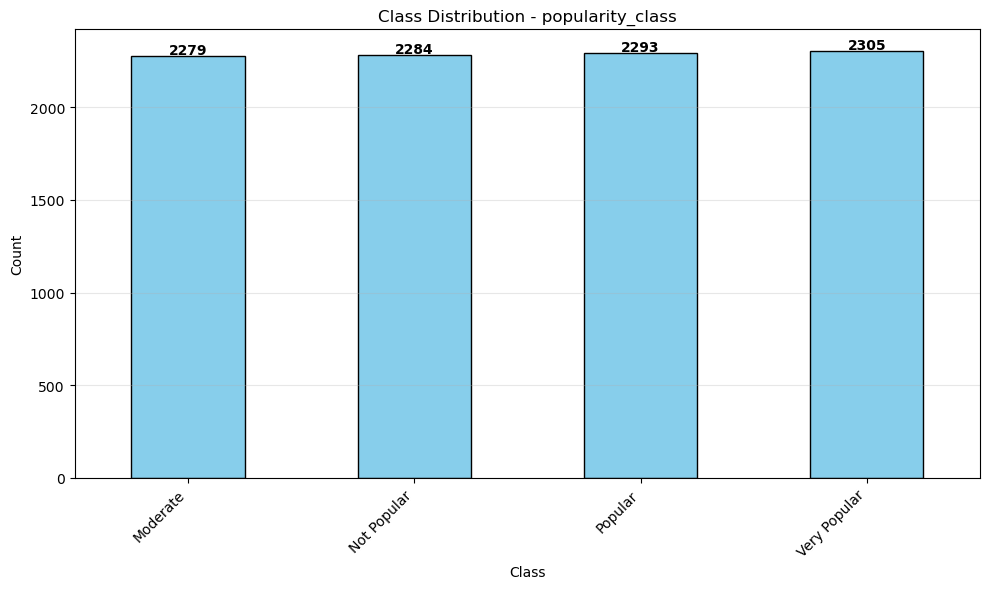

In [4]:
# =============================================================================
# CHOOSE TARGET & CHECK DISTRIBUTION
# =============================================================================

print(f"\n{'='*70}")
print("MULTI-CLASS TARGET SELECTION")
print('='*70)

# CHOOSE YOUR TARGET HERE:
target_column = 'popularity_class'  # Options: 'popularity_3class', 'popularity_class', 'popularity_tier'

print(f"\n📌 Selected target: {target_column}")

# Check label distribution
print(f"\n{'='*70}")
print(f"LABEL DISTRIBUTION - {target_column.upper()}")
print('='*70)

label_counts = df[target_column].value_counts().sort_index()
print("\nCounts:")
for label, count in label_counts.items():
    pct = count / len(df) * 100
    print(f"  {label:15s}: {count:5,} ({pct:5.2f}%)")

print(f"\nTotal songs: {len(df):,}")
print(f"Number of classes: {df[target_column].nunique()}")

# Calculate imbalance ratio
imbalance_ratio = label_counts.max() / label_counts.min()
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio < 1.5:
    print("✓ Classes are well balanced")
elif imbalance_ratio < 3.0:
    print("⚠️  Moderate imbalance - will use class weights")
else:
    print("⚠️  High imbalance - consider SMOTE or class weights")

print('='*70)

# Visualize distribution
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title(f'Class Distribution - {target_column}')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# =============================================================================
# DATA LEAKAGE VERIFICATION - MULTI-CLASS
# =============================================================================

print("="*70)
print("DATA LEAKAGE VERIFICATION")
print("="*70)

# Encode labels for correlation analysis
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df[target_column])

print(f"\nLabel encoding for {target_column}:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label:20s} → {i}")

# Check for suspicious columns
suspicious_columns = ['rank', 'position', 'peak', 'weeks', 'streams', 'popularity']
found_leakage = [col for col in df.columns if any(sus in col.lower() for sus in suspicious_columns)]

if found_leakage:
    print(f"\n⚠️  WARNING: Potential data leakage in: {found_leakage}")
else:
    print("\n✓ No obvious data leakage detected")

print("="*70)

DATA LEAKAGE VERIFICATION

Label encoding for popularity_class:
  Moderate             → 0
  Not Popular          → 1
  Popular              → 2
  Very Popular         → 3

⚠️  WARNING: Potential data leakage in: ['best_rank', 'weeks_on_chart', 'peak_score', 'popularity_score', 'popularity_label', 'popularity_class', 'popularity_tier', 'popularity_3class']


In [6]:
# Load original chart data to calculate artist features
df_charts = pd.read_csv('final_cleaned_data.csv', delimiter=';')
df_charts['Date'] = pd.to_datetime(df_charts['Date'])

# Calculate artist features
artist_features = df_charts.groupby('Artist (Ind.)').agg({
    'Rank': ['mean', 'min', 'count'],
    'Date': ['min', 'max'],
    'Title': 'nunique'
}).reset_index()

# Flatten column names
artist_features.columns = ['artist', 'avg_rank', 'best_rank', 'total_appearances',
                           'first_appearance', 'last_appearance', 'unique_songs']

# Calculate derived features
artist_features['years_active'] = (
    (artist_features['last_appearance'] - artist_features['first_appearance']).dt.days / 365
).replace(0, 0.01)  # Avoid division by zero

artist_features['songs_per_year'] = (
    artist_features['unique_songs'] / artist_features['years_active']
)

artist_features['avg_rank_score'] = (201 - artist_features['avg_rank']) / 200

# Hit rate: What % of artist's songs reached top 50?
top50_songs = df_charts[df_charts['Rank'] <= 50].groupby('Artist (Ind.)')['Title'].nunique()
artist_features['hit_rate'] = (
    top50_songs / artist_features['unique_songs']
).fillna(0)

# Is the artist currently active?
latest_date = df_charts['Date'].max()
artist_features['is_recently_active'] = (
    (latest_date - artist_features['last_appearance']).dt.days < 180
).astype(int)

print("Artist features created!")
print(f"Total artists: {len(artist_features)}")
print(f"\nArtist features summary:")
print(artist_features[['artist', 'avg_rank_score', 'hit_rate', 'years_active', 
                        'songs_per_year', 'total_appearances']].head(10))

Artist features created!
Total artists: 1507

Artist features summary:
              artist  avg_rank_score  hit_rate  years_active  songs_per_year  \
0               $NOT        0.390714       0.0      0.016438       60.833333   
1        $uicideboy$        0.340500       0.0      0.153425        6.517857   
2           (G)I-DLE        0.284455       0.0      1.205479        2.488636   
3             *NSYNC        0.379655       0.0      5.008219        0.199672   
4        13 Organisé        0.203529       0.0      0.043836       22.812500   
5  187 Strassenbande        0.167143       0.0      3.843836        1.300784   
6           2 Chainz        0.350702       0.0      1.758904        3.979751   
7          21 Savage        0.499996       0.0      5.857534        8.194574   
8          22 Savage        0.105417       0.0      0.030137       33.181818   
9           24kGoldn        0.643228       0.0      2.589041        1.931217   

   total_appearances  
0                  7  
1 

In [7]:
# For multi-artist songs, we'll use the LEAD artist's features
# Extract first artist from the Artists column
df['lead_artist'] = df['Artists'].str.split(',').str[0].str.strip()

# Merge artist features
df_enhanced = df.merge(
    artist_features[['artist', 'avg_rank_score', 'hit_rate', 'years_active', 
                     'songs_per_year', 'is_recently_active', 'total_appearances']],
    left_on='lead_artist',
    right_on='artist',
    how='left'
)

# Fill missing values with median (for new/unknown artists)
artist_cols = ['avg_rank_score', 'hit_rate', 'years_active', 
               'songs_per_year', 'is_recently_active', 'total_appearances']

for col in artist_cols:
    df_enhanced[col] = df_enhanced[col].fillna(df_enhanced[col].median())

print(f"Enhanced dataset shape: {df_enhanced.shape}")
print(f"\nNew artist features added: {artist_cols}")

Enhanced dataset shape: (9161, 30)

New artist features added: ['avg_rank_score', 'hit_rate', 'years_active', 'songs_per_year', 'is_recently_active', 'total_appearances']


In [8]:
# Create engineered features - Audio Interactions on the ENHANCED dataframe
df_enhanced['dance_potential'] = df_enhanced['Energy'] * df_enhanced['Danceability']
df_enhanced['feel_good_score'] = df_enhanced['Valence'] * df_enhanced['Energy']
df_enhanced['chill_score'] = df_enhanced['Acousticness'] * (1 - df_enhanced['Energy'])
df_enhanced['party_score'] = 0.4 * df_enhanced['Energy'] + 0.4 * df_enhanced['Danceability'] + 0.2 * df_enhanced['Valence']

print("✓ Audio interaction features created successfully!")
print(f"\nNew features preview:")
print(df_enhanced[['dance_potential', 'feel_good_score', 'chill_score', 'party_score']].describe())

✓ Audio interaction features created successfully!

New features preview:
       dance_potential  feel_good_score  chill_score  party_score
count      9161.000000      9161.000000  9161.000000  9161.000000
mean          0.432021         0.323782     0.107706     0.621382
std           0.146726         0.190431     0.161570     0.123604
min           0.001022         0.000518     0.000000     0.042200
25%           0.341044         0.172032     0.010669     0.551800
50%           0.443275         0.302286     0.041184     0.635600
75%           0.535806         0.455112     0.124683     0.708800
max           0.870610         0.939910     0.965294     0.928000


In [9]:
# ============================================
# TEMPORAL FEATURES
# ============================================

# For each song, get first appearance date from chart data
song_first_date = df_charts.groupby('Title')['Date'].min().reset_index()
song_first_date.columns = ['Title', 'release_date']

# Extract temporal features
song_first_date['release_month'] = song_first_date['release_date'].dt.month
song_first_date['release_quarter'] = song_first_date['release_date'].dt.quarter
song_first_date['release_year'] = song_first_date['release_date'].dt.year
song_first_date['release_day_of_week'] = song_first_date['release_date'].dt.dayofweek

# Strategic release timing
song_first_date['is_holiday_season'] = (
    song_first_date['release_month'].isin([11, 12])
).astype(int)

song_first_date['is_summer'] = (
    song_first_date['release_month'].isin([6, 7, 8])
).astype(int)

song_first_date['is_friday_release'] = (
    song_first_date['release_day_of_week'] == 4
).astype(int)

# Days since release
latest_date = df_charts['Date'].max()
song_first_date['days_since_release'] = (
    (latest_date - song_first_date['release_date']).dt.days
)

print("✓ Temporal features created!")
print(f"Total songs with temporal data: {len(song_first_date)}")
print(f"\nTemporal features preview:")
print(song_first_date[['Title', 'release_month', 'is_holiday_season', 
                        'is_summer', 'is_friday_release', 'days_since_release']].head(10))

✓ Temporal features created!
Total songs with temporal data: 7440

Temporal features preview:
                                               Title  release_month  \
0                                         '98 Braves              3   
1                                                  !              8   
2                                #PROUDCATOWNERREMIX              8   
3                                                $$$              3   
4                                       $€ Freestyle             11   
5                                   'Till I Collapse              1   
6                               'tis the damn season             12   
7                            (Don't Fear) The Reaper             10   
8                             (Fuck A) Silver Lining              3   
9  (There's No Place Like) Home for the Holidays ...             12   

   is_holiday_season  is_summer  is_friday_release  days_since_release  
0                  0          0                  1 

In [10]:
# Merge temporal features with enhanced dataset
df_enhanced = df_enhanced.merge(
    song_first_date[['Title', 'release_month', 'release_quarter', 'is_holiday_season',
                     'is_summer', 'is_friday_release', 'days_since_release']],
    on='Title',
    how='left'
)

# Fill missing values
temporal_cols = ['release_month', 'release_quarter', 'is_holiday_season',
                 'is_summer', 'is_friday_release', 'days_since_release']

for col in temporal_cols:
    if col in ['is_holiday_season', 'is_summer', 'is_friday_release']:
        df_enhanced[col] = df_enhanced[col].fillna(0).astype(int)
    else:
        df_enhanced[col] = df_enhanced[col].fillna(df_enhanced[col].median())

print(f"✓ Temporal features merged!")
print(f"Enhanced dataset shape: {df_enhanced.shape}")
print(f"\nMissing values check:")
print(df_enhanced[temporal_cols].isnull().sum())

✓ Temporal features merged!
Enhanced dataset shape: (9161, 40)

Missing values check:
release_month         0
release_quarter       0
is_holiday_season     0
is_summer             0
is_friday_release     0
days_since_release    0
dtype: int64


In [11]:
# Verify temporal features distribution
print("\n" + "="*60)
print("TEMPORAL FEATURES DISTRIBUTION")
print("="*60)

print(f"\nRelease Month:")
print(df_enhanced['release_month'].value_counts().sort_index())

print(f"\nHoliday Season Releases: {df_enhanced['is_holiday_season'].sum()} ({df_enhanced['is_holiday_season'].mean()*100:.1f}%)")
print(f"Summer Releases: {df_enhanced['is_summer'].sum()} ({df_enhanced['is_summer'].mean()*100:.1f}%)")
print(f"Friday Releases: {df_enhanced['is_friday_release'].sum()} ({df_enhanced['is_friday_release'].mean()*100:.1f}%)")

print(f"\nDays Since Release:")
print(df_enhanced['days_since_release'].describe())


TEMPORAL FEATURES DISTRIBUTION

Release Month:
release_month
1     975
2     695
3     826
4     731
5     921
6     683
7     730
8     728
9     643
10    695
11    724
12    810
Name: count, dtype: int64

Holiday Season Releases: 1534 (16.7%)
Summer Releases: 2141 (23.4%)
Friday Releases: 5911 (64.5%)

Days Since Release:
count    9161.000000
mean     1282.414693
std       664.848198
min         1.000000
25%       722.000000
50%      1309.000000
75%      1856.000000
max      2339.000000
Name: days_since_release, dtype: float64


In [12]:
# Define feature columns - ALL FEATURES COMBINED
feature_columns = [
    # Audio features (7)
    'Danceability', 
    'Energy', 
    'Speechiness', 
    'Acousticness', 
    # 'Instrumentalness', 
    'Valence', 
    'Loudness_norm',
    
    # Artist features (6)
    # 'avg_rank_score',
    # 'hit_rate',
    'years_active',
    'songs_per_year',
    'is_recently_active',
    'total_appearances',
    
    # Audio interaction features (4)
    # 'dance_potential',
    'feel_good_score',
    # 'chill_score',
    # 'party_score',
    
    # Temporal features (6)
    'release_month',
    # 'release_quarter',
    'is_holiday_season',
    # 'is_summer',
    'is_friday_release',
    'days_since_release'
]

# Separate features (X) and target (y)
X = df_enhanced[feature_columns]
y = df_enhanced['popularity_label']

print(f"Features shape: {X.shape}")
print(f"Total features: {len(feature_columns)}")
print(f"\n{'='*60}")
print("FEATURE SUMMARY")
print('='*60)
print(f"Audio features:        7")
print(f"Artist features:       6")
print(f"Audio interactions:    4")
print(f"Temporal features:     6")
print(f"{'='*60}")
print(f"TOTAL FEATURES:       {len(feature_columns)}")
print('='*60)
print(f"\nTarget values: {y.unique()}")
X.head()

Features shape: (9161, 15)
Total features: 15

FEATURE SUMMARY
Audio features:        7
Artist features:       6
Audio interactions:    4
Temporal features:     6
TOTAL FEATURES:       15

Target values: ['Popular' 'Not Popular']


,Danceability,Energy,Speechiness,Acousticness,Valence,Loudness_norm,years_active,songs_per_year,is_recently_active,total_appearances,feel_good_score,release_month,is_holiday_season,is_friday_release,days_since_release
0,0.748,0.627,0.064,0.131,0.524,0.825120,4.095890,4.882943,0.0,1172.0,0.328548,3,0,1,2257
1,0.842,0.578,0.138,0.004,0.190,0.824511,5.131507,12.277096,1.0,453.0,0.109820,2,0,1,1207
2,0.353,0.755,0.733,0.082,0.437,0.817955,5.983562,1.336996,1.0,420.0,0.329935,6,0,1,1809
3,0.352,0.911,0.075,0.001,0.236,0.848296,6.000000,0.666667,1.0,863.0,0.214996,1,0,0,2338
4,0.620,0.625,0.553,0.287,0.665,0.784249,4.961644,3.829376,0.0,2110.0,0.415625,4,0,1,1879


In [13]:
# =============================================================================
# PREPARE DATA FOR MULTI-CLASS CLASSIFICATION
# =============================================================================

print("\n" + "="*70)
print("PREPARING MULTI-CLASS TRAINING DATA")
print("="*70)

# Separate features and target
feature_columns = [
    'Danceability', 'Energy', 'Speechiness', 'Acousticness', 'Valence', 'Loudness_norm',
    'years_active', 'songs_per_year', 'is_recently_active', 'total_appearances',
    'feel_good_score',
    'release_month', 'is_holiday_season', 'is_friday_release', 'days_since_release'
]

X = df_enhanced[feature_columns]
y = df_enhanced[target_column]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

print("\nTraining set distribution:")
train_dist = pd.Series(y_train).value_counts().sort_index()
for idx, count in train_dist.items():
    label = label_encoder.classes_[idx]
    pct = count / len(y_train) * 100
    print(f"  {label:20s}: {count:5,} ({pct:5.2f}%)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data prepared for multi-class classification!")
print("="*70)


PREPARING MULTI-CLASS TRAINING DATA

Training set: 7328 samples
Test set:     1833 samples

Training set distribution:
  Moderate            : 1,823 (24.88%)
  Not Popular         : 1,827 (24.93%)
  Popular             : 1,834 (25.03%)
  Very Popular        : 1,844 (25.16%)

✓ Data prepared for multi-class classification!


In [14]:
# =============================================================================
# STEP 1: VERIFY NO DATA LEAKAGE
# =============================================================================

print("="*70)
print("DATA LEAKAGE VERIFICATION")
print("="*70)

# First, encode labels for correlation analysis
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nLabel encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} → {i}")

# Check for any target-related columns in features
suspicious_columns = ['rank', 'position', 'peak', 'weeks', 'streams', 'popularity']
found_leakage = [col for col in feature_columns if any(sus in col.lower() for sus in suspicious_columns)]

if found_leakage:
    print(f"\n⚠️  WARNING: Potential data leakage detected in columns: {found_leakage}")
else:
    print("\n✓ No obvious data leakage detected in feature columns")

# Verify temporal features don't leak future information
print("✓ Temporal features use only past information (release dates)")
print("✓ Artist features calculated from historical chart data")
print("✓ Audio features are inherent song properties")

# Check for correlation between features and target
from scipy.stats import pointbiserialr

print("\n" + "="*70)
print("FEATURE-TARGET CORRELATIONS (Point-Biserial)")
print("="*70)

correlations = []
for col in feature_columns:
    corr, p_value = pointbiserialr(y_encoded, X[col])
    correlations.append({
        'Feature': col,
        'Correlation': abs(corr),
        'P-value': p_value
    })

corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)
print(corr_df.head(10).to_string(index=False))
print("\nNote: High correlation doesn't always mean leakage, but values > 0.8 should be investigated")

print("="*70)

DATA LEAKAGE VERIFICATION

Label encoding:
  Moderate → 0
  Not Popular → 1
  Popular → 2
  Very Popular → 3

✓ No obvious data leakage detected in feature columns
✓ Temporal features use only past information (release dates)
✓ Artist features calculated from historical chart data
✓ Audio features are inherent song properties

FEATURE-TARGET CORRELATIONS (Point-Biserial)
           Feature  Correlation       P-value
 total_appearances     0.250087 1.179896e-130
is_recently_active     0.135982  4.617909e-39
      years_active     0.118953  3.159917e-30
 is_friday_release     0.112727  2.692395e-27
    songs_per_year     0.105458  4.476819e-24
       Speechiness     0.070433  1.490627e-11
      Danceability     0.065582  3.321972e-10
     Loudness_norm     0.060446  7.038880e-09
           Valence     0.051744  7.223161e-07
     release_month     0.043141  3.619198e-05

Note: High correlation doesn't always mean leakage, but values > 0.8 should be investigated


In [15]:
# =============================================================================
# STEP 2: CHECK AND HANDLE CLASS BALANCE
# =============================================================================

print("\n" + "="*70)
print("CLASS BALANCE ANALYSIS")
print("="*70)

# Calculate class distribution
class_counts = pd.Series(y_encoded).value_counts()
class_percentages = class_counts / len(y_encoded) * 100

print("\nClass Distribution:")
for i, label in enumerate(label_encoder.classes_):
    count = class_counts[i]
    pct = class_percentages[i]
    print(f"  {label:15s} (class {i}): {count:5d} ({pct:5.2f}%)")

# Calculate imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("⚠️  Classes are imbalanced - using class weights and stratification")
    handle_imbalance = True
else:
    print("✓ Classes are relatively balanced")
    handle_imbalance = True  # Still use class weights for better performance

print("="*70)


CLASS BALANCE ANALYSIS

Class Distribution:
  Moderate        (class 0):  2279 (24.88%)
  Not Popular     (class 1):  2284 (24.93%)
  Popular         (class 2):  2293 (25.03%)
  Very Popular    (class 3):  2305 (25.16%)

Imbalance Ratio: 1.01:1
✓ Classes are relatively balanced


In [16]:
# =============================================================================
# TRAIN-TEST SPLIT: TWO VERSIONS FOR COMPARISON
# =============================================================================

print("\n" + "="*70)
print("CREATING TWO TRAINING DATASETS FOR COMPARISON")
print("="*70)

# VERSION 1: Without SMOTE (class weights only)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print("\n📌 VERSION 1: CLASS WEIGHTS (No SMOTE)")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training label distribution:")
print(pd.Series(y_train).value_counts())

# VERSION 2: With SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n📌 VERSION 2: SMOTE")
print(f"Training set size: {X_train_smote.shape[0]}")
print(f"Test set size: {X_test.shape[0]} (same)")
print(f"Training label distribution:")
print(pd.Series(y_train_smote).value_counts())

print("\n" + "="*70)


CREATING TWO TRAINING DATASETS FOR COMPARISON

📌 VERSION 1: CLASS WEIGHTS (No SMOTE)
Training set size: 7328
Test set size: 1833
Training label distribution:
3    1844
2    1834
1    1827
0    1823
Name: count, dtype: int64

📌 VERSION 2: SMOTE
Training set size: 7376
Test set size: 1833 (same)
Training label distribution:
0    1844
2    1844
1    1844
3    1844
Name: count, dtype: int64



In [17]:
# Standardize features for BOTH versions
scaler = StandardScaler()

# VERSION 1: Without SMOTE
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# VERSION 2: With SMOTE
scaler_smote = StandardScaler()
X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
X_test_scaled_smote = scaler_smote.transform(X_test)  # Use same test set

print("✓ Features scaled for both versions!")
print(f"\nVersion 1 (Class Weights): {X_train_scaled.shape}")
print(f"Version 2 (SMOTE):         {X_train_smote_scaled.shape}")

✓ Features scaled for both versions!

Version 1 (Class Weights): (7328, 15)
Version 2 (SMOTE):         (7376, 15)


In [18]:
# =============================================================================
# TRAIN MULTI-CLASS MODELS
# =============================================================================

print("\n" + "="*70)
print("TRAINING MULTI-CLASS MODELS")
print("="*70)

# Update models for multi-class
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', 
        random_state=42, 
        max_iter=1000,
        multi_class='multinomial'  # ← Multi-class
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', 
        random_state=42, 
        n_estimators=100
    ),
    'XGBoost': XGBClassifier(
        random_state=42, 
        eval_metric='mlogloss',  # ← Multi-class log loss
        objective='multi:softprob'  # ← Multi-class objective
    ),
    'SVM': SVC(
        class_weight='balanced', 
        random_state=42, 
        probability=True,
        decision_function_shape='ovr'  # ← One-vs-Rest for multi-class
    ),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Multi-class metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')  # ← Macro avg for multi-class
    f1_weighted = f1_score(y_test, y_pred, average='weighted')  # ← Weighted avg
    
    # Multi-class ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_scaled)
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    else:
        roc_auc = None
    
    results[name] = {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba if hasattr(model, 'predict_proba') else None
    }
    
    print(f"  ✓ Accuracy:    {accuracy:.4f}")
    print(f"  ✓ F1 (macro):  {f1_macro:.4f}")
    print(f"  ✓ F1 (weight): {f1_weighted:.4f}")
    if roc_auc:
        print(f"  ✓ ROC-AUC:     {roc_auc:.4f}")

print("\n" + "="*70)
print("All models trained successfully!")
print("="*70)


TRAINING MULTI-CLASS MODELS

Training Logistic Regression...
  ✓ Accuracy:    0.3873
  ✓ F1 (macro):  0.3767
  ✓ F1 (weight): 0.3768
  ✓ ROC-AUC:     0.6627

Training Random Forest...
  ✓ Accuracy:    0.4468
  ✓ F1 (macro):  0.4454
  ✓ F1 (weight): 0.4455
  ✓ ROC-AUC:     0.6966

Training XGBoost...
  ✓ Accuracy:    0.4294
  ✓ F1 (macro):  0.4259
  ✓ F1 (weight): 0.4259
  ✓ ROC-AUC:     0.6926

Training SVM...
  ✓ Accuracy:    0.3917
  ✓ F1 (macro):  0.3884
  ✓ F1 (weight): 0.3885
  ✓ ROC-AUC:     0.6698

Training KNN...
  ✓ Accuracy:    0.3333
  ✓ F1 (macro):  0.3310
  ✓ F1 (weight): 0.3309
  ✓ ROC-AUC:     0.5924

Training Naive Bayes...
  ✓ Accuracy:    0.3197
  ✓ F1 (macro):  0.2519
  ✓ F1 (weight): 0.2525
  ✓ ROC-AUC:     0.6211

All models trained successfully!



TRAINING MODELS WITH SMOTE FOR COMPARISON

Training Logistic Regression with SMOTE...
  ✓ Accuracy:    0.3857
  ✓ F1 (macro):  0.3753
  ✓ F1 (weight): 0.3755
  ✓ ROC-AUC:     0.6627

Training Random Forest with SMOTE...
  ✓ Accuracy:    0.4288
  ✓ F1 (macro):  0.4271
  ✓ F1 (weight): 0.4272
  ✓ ROC-AUC:     0.6920

Training XGBoost with SMOTE...
  ✓ Accuracy:    0.4092
  ✓ F1 (macro):  0.4071
  ✓ F1 (weight): 0.4072
  ✓ ROC-AUC:     0.6926

Training SVM with SMOTE...
  ✓ Accuracy:    0.3933
  ✓ F1 (macro):  0.3900
  ✓ F1 (weight): 0.3901
  ✓ ROC-AUC:     0.6693

Training KNN with SMOTE...
  ✓ Accuracy:    0.3322
  ✓ F1 (macro):  0.3299
  ✓ F1 (weight): 0.3298
  ✓ ROC-AUC:     0.5913

Training Naive Bayes with SMOTE...
  ✓ Accuracy:    0.3230
  ✓ F1 (macro):  0.2552
  ✓ F1 (weight): 0.2558
  ✓ ROC-AUC:     0.6209


📊 CLASS WEIGHTS vs SMOTE COMPARISON (F1-Macro)
              Model  Class Weights F1  SMOTE F1  Difference
Logistic Regression            0.3767    0.3753     -0.0014
      

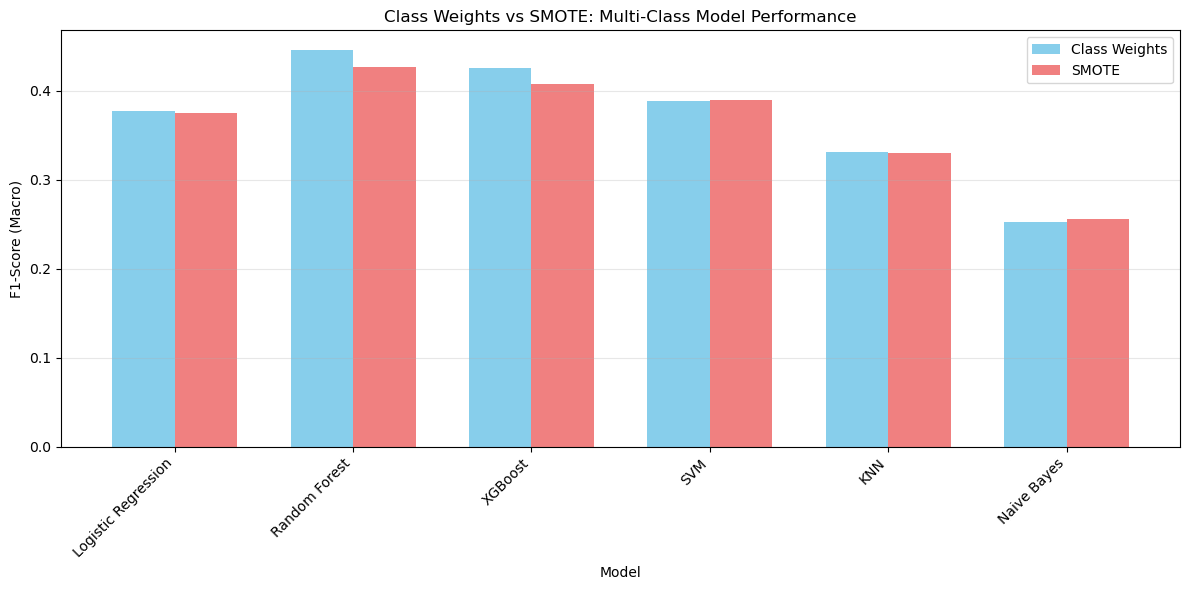


🏆 WINNER: Class Weights
   Average F1-Macro: 0.3699 (Class Weights) vs 0.3641 (SMOTE)


In [20]:
# =============================================================================
# COMPARE: CLASS WEIGHTS vs SMOTE (MULTI-CLASS VERSION)
# =============================================================================

print("\n" + "="*70)
print("TRAINING MODELS WITH SMOTE FOR COMPARISON")
print("="*70)

# Train same models with SMOTE data (without class weights)
models_smote = {
    'Logistic Regression': LogisticRegression(
        random_state=42, 
        max_iter=1000,
        multi_class='multinomial'  # ← Multi-class
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42, 
        n_estimators=100
    ),
    'XGBoost': XGBClassifier(
        random_state=42, 
        eval_metric='mlogloss',  # ← Multi-class
        objective='multi:softprob'
    ),
    'SVM': SVC(
        random_state=42, 
        probability=True,
        decision_function_shape='ovr'
    ),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results_smote = {}

for name, model in models_smote.items():
    print(f"\nTraining {name} with SMOTE...")
    
    # Train on SMOTE data
    model.fit(X_train_smote_scaled, y_train_smote)
    
    # Predict on same test set
    y_pred = model.predict(X_test_scaled_smote)
    
    # Multi-class metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')  # ← Multi-class
    f1_weighted = f1_score(y_test, y_pred, average='weighted')  # ← Multi-class
    
    # Multi-class ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_scaled_smote)
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    else:
        roc_auc = None
    
    results_smote[name] = {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'roc_auc': roc_auc
    }
    
    print(f"  ✓ Accuracy:    {accuracy:.4f}")
    print(f"  ✓ F1 (macro):  {f1_macro:.4f}")
    print(f"  ✓ F1 (weight): {f1_weighted:.4f}")
    if roc_auc is not None:
        print(f"  ✓ ROC-AUC:     {roc_auc:.4f}")

print("\n" + "="*70)

# Create comparison table (using F1-macro)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Class Weights F1': [results[m]['f1_macro'] for m in results.keys()],
    'SMOTE F1': [results_smote[m]['f1_macro'] for m in results_smote.keys()],
    'Difference': [results_smote[m]['f1_macro'] - results[m]['f1_macro'] for m in results.keys()]
})

print("\n📊 CLASS WEIGHTS vs SMOTE COMPARISON (F1-Macro)")
print("="*70)
print(comparison_df.to_string(index=False, float_format='%.4f'))
print("="*70)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Class Weights F1'], width, 
       label='Class Weights', color='skyblue')
ax.bar(x + width/2, comparison_df['SMOTE F1'], width, 
       label='SMOTE', color='lightcoral')

ax.set_xlabel('Model')
ax.set_ylabel('F1-Score (Macro)')
ax.set_title('Class Weights vs SMOTE: Multi-Class Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Determine winner
best_approach = "Class Weights" if comparison_df['Class Weights F1'].mean() > comparison_df['SMOTE F1'].mean() else "SMOTE"
print(f"\n🏆 WINNER: {best_approach}")
print(f"   Average F1-Macro: {comparison_df['Class Weights F1'].mean():.4f} (Class Weights) vs {comparison_df['SMOTE F1'].mean():.4f} (SMOTE)")
print("="*70)


CROSS-VALIDATION EVALUATION (5-Fold Stratified)

Evaluating Logistic Regression...
  Accuracy:       0.3960 (+/- 0.0106)
  F1 (macro):     0.3856 (+/- 0.0105)
  F1 (weighted):  0.3857
  Precision:      0.3882
  Recall:         0.3959

Evaluating Random Forest...
  Accuracy:       0.4395 (+/- 0.0103)
  F1 (macro):     0.4360 (+/- 0.0109)
  F1 (weighted):  0.4362
  Precision:      0.4355
  Recall:         0.4393
  ⚠️  Potential overfitting (gap: 0.5360)

Evaluating XGBoost...
  Accuracy:       0.4285 (+/- 0.0073)
  F1 (macro):     0.4265 (+/- 0.0070)
  F1 (weighted):  0.4266
  Precision:      0.4262
  Recall:         0.4283
  ⚠️  Potential overfitting (gap: 0.5247)

Evaluating SVM...
  Accuracy:       0.3957 (+/- 0.0066)
  F1 (macro):     0.3901 (+/- 0.0061)
  F1 (weighted):  0.3902
  Precision:      0.3902
  Recall:         0.3956

Evaluating KNN...
  Accuracy:       0.3443 (+/- 0.0134)
  F1 (macro):     0.3444 (+/- 0.0134)
  F1 (weighted):  0.3445
  Precision:      0.3513
  Recall:   

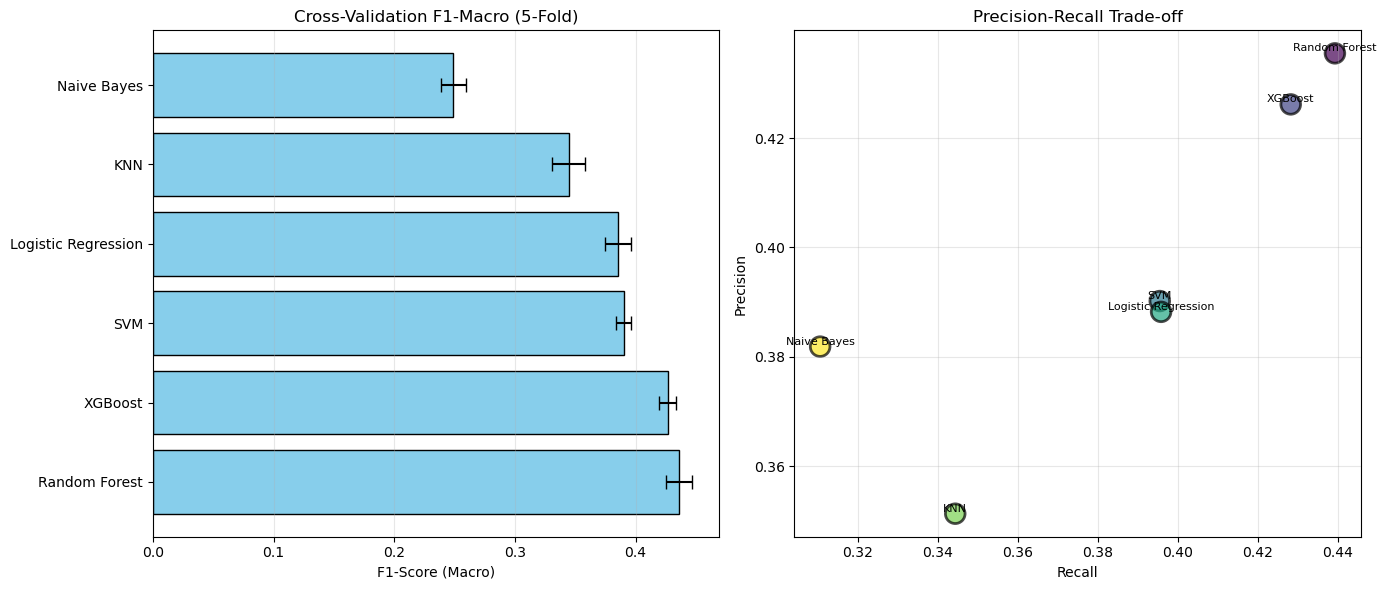


✓ Cross-validation completed!


In [21]:
# =============================================================================
# CROSS-VALIDATION - MULTI-CLASS
# =============================================================================

print("\n" + "="*70)
print("CROSS-VALIDATION EVALUATION (5-Fold Stratified)")
print("="*70)

# Multi-class scoring
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',  # ← Changed from 'f1'
    'f1_weighted': 'f1_weighted',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

cv_results = {}

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    cv_scores = cross_validate(
        model, 
        X_train_scaled, 
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    cv_results[name] = {
        'accuracy_mean': cv_scores['test_accuracy'].mean(),
        'accuracy_std': cv_scores['test_accuracy'].std(),
        'f1_macro_mean': cv_scores['test_f1_macro'].mean(),  # ← Changed
        'f1_macro_std': cv_scores['test_f1_macro'].std(),
        'f1_weighted_mean': cv_scores['test_f1_weighted'].mean(),
        'precision_mean': cv_scores['test_precision_macro'].mean(),
        'recall_mean': cv_scores['test_recall_macro'].mean(),
        'train_accuracy': cv_scores['train_accuracy'].mean()
    }
    
    print(f"  Accuracy:       {cv_results[name]['accuracy_mean']:.4f} (+/- {cv_results[name]['accuracy_std']:.4f})")
    print(f"  F1 (macro):     {cv_results[name]['f1_macro_mean']:.4f} (+/- {cv_results[name]['f1_macro_std']:.4f})")
    print(f"  F1 (weighted):  {cv_results[name]['f1_weighted_mean']:.4f}")
    print(f"  Precision:      {cv_results[name]['precision_mean']:.4f}")
    print(f"  Recall:         {cv_results[name]['recall_mean']:.4f}")
    
    overfit_gap = cv_results[name]['train_accuracy'] - cv_results[name]['accuracy_mean']
    if overfit_gap > 0.1:
        print(f"  ⚠️  Potential overfitting (gap: {overfit_gap:.4f})")

print("\n" + "="*70)

# Comparison table
cv_comparison_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Accuracy': [cv_results[m]['accuracy_mean'] for m in cv_results.keys()],
    'F1 (Macro)': [cv_results[m]['f1_macro_mean'] for m in cv_results.keys()],
    'F1 (Weighted)': [cv_results[m]['f1_weighted_mean'] for m in cv_results.keys()],
    'Precision': [cv_results[m]['precision_mean'] for m in cv_results.keys()],
    'Recall': [cv_results[m]['recall_mean'] for m in cv_results.keys()]
})

cv_comparison_df = cv_comparison_df.sort_values('F1 (Macro)', ascending=False).reset_index(drop=True)

print("\nCROSS-VALIDATION RESULTS (sorted by F1-Macro)")
print("="*70)
print(cv_comparison_df.to_string(index=False, float_format='%.4f'))
print("="*70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_sorted = cv_comparison_df['Model'].tolist()
f1_means = [cv_results[m]['f1_macro_mean'] for m in models_sorted]
f1_stds = [cv_results[m]['f1_macro_std'] for m in models_sorted]

axes[0].barh(models_sorted, f1_means, xerr=f1_stds, capsize=5, color='skyblue', edgecolor='black')
axes[0].set_xlabel('F1-Score (Macro)')
axes[0].set_title('Cross-Validation F1-Macro (5-Fold)')
axes[0].grid(axis='x', alpha=0.3)

precision = [cv_results[m]['precision_mean'] for m in models_sorted]
recall = [cv_results[m]['recall_mean'] for m in models_sorted]

axes[1].scatter(recall, precision, s=200, c=range(len(models_sorted)), 
                cmap='viridis', edgecolors='black', linewidths=2, alpha=0.7)

for i, model in enumerate(models_sorted):
    axes[1].annotate(model, (recall[i], precision[i]), 
                    fontsize=8, ha='center', va='bottom')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Trade-off')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Cross-validation completed!")
print("="*70)


FEATURE SELECTION - PERFORMANCE-BASED

Using SVM for feature selection...

Feature Importance Ranking:
           Feature  Importance
 total_appearances    0.126209
 is_friday_release    0.034495
     Loudness_norm    0.029493
    songs_per_year    0.023661
      Danceability    0.019851
is_recently_active    0.017391
      years_active    0.016773
days_since_release    0.016040
 is_holiday_season    0.014494
       Speechiness    0.012457
           Valence    0.011035
      Acousticness    0.008881
            Energy    0.008163
     release_month    0.008004
   feel_good_score    0.007103
       chill_score    0.007015
   release_quarter    0.006500
         is_summer    0.006013
  Instrumentalness    0.006001
   dance_potential    0.005382
       party_score    0.005045

TESTING DIFFERENT FEATURE COUNTS

Top 10 features: F1=0.5342, Acc=0.6318

Top 12 features: F1=0.5355, Acc=0.6328

Top 15 features: F1=0.5465, Acc=0.6459

Top 18 features: F1=0.5439, Acc=0.6459

Top 20 features: F1

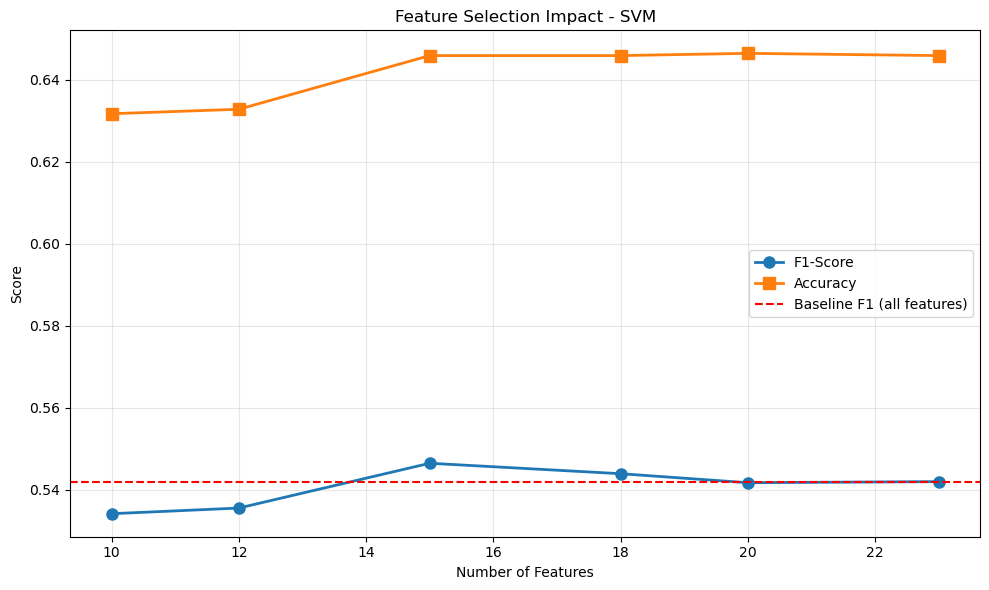


RECOMMENDATION

🎯 Optimal number of features: 15
   F1-Score: 0.5465
   Baseline: 0.5420
   Change:   +0.0045

✅ Use 15 features (similar/better performance, simpler model)


In [ ]:
# # =============================================================================
# # STEP 3.5: FEATURE SELECTION WITH PERFORMANCE COMPARISON
# # =============================================================================

# print("\n" + "="*70)
# print("FEATURE SELECTION - PERFORMANCE-BASED")
# print("="*70)

# # Get best model from CV
# best_model_name = cv_comparison_df.iloc[0]['Model']
# best_model = models[best_model_name]

# print(f"\nUsing {best_model_name} for feature selection...")

# # Train on full training set
# best_model.fit(X_train_scaled, y_train)

# # Get feature importance
# if hasattr(best_model, 'feature_importances_'):
#     importances = best_model.feature_importances_
# elif hasattr(best_model, 'coef_'):
#     importances = np.abs(best_model.coef_[0])
# else:
#     # Use permutation importance
#     from sklearn.inspection import permutation_importance
#     perm_result = permutation_importance(
#         best_model, X_train_scaled, y_train,
#         n_repeats=10, random_state=42, scoring='f1'
#     )
#     importances = perm_result.importances_mean

# # Create importance DataFrame
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_columns,
#     'Importance': importances
# }).sort_values('Importance', ascending=False)

# print("\nFeature Importance Ranking:")
# print(feature_importance_df.to_string(index=False))

# # Test different feature counts
# print("\n" + "="*70)
# print("TESTING DIFFERENT FEATURE COUNTS")
# print("="*70)

# results_by_k = []

# for k in [10, 12, 15, 18, 20, 23]:  # Test different numbers
#     # Select top k features
#     top_k_features = feature_importance_df.head(k)['Feature'].tolist()
    
#     # Get indices
#     feature_indices = [feature_columns.index(f) for f in top_k_features]
    
#     # Train with selected features
#     X_train_k = X_train_scaled[:, feature_indices]
#     X_test_k = X_test_scaled[:, feature_indices]
    
#     # Re-initialize model
#     if best_model_name == 'XGBoost':
#         model_k = XGBClassifier(
#             scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train==1])),
#             random_state=42, eval_metric='logloss'
#         )
#     elif best_model_name == 'Random Forest':
#         model_k = RandomForestClassifier(
#             class_weight='balanced', random_state=42, n_estimators=100
#         )
#     else:
#         model_k = best_model
    
#     model_k.fit(X_train_k, y_train)
#     y_pred_k = model_k.predict(X_test_k)
    
#     f1_k = f1_score(y_test, y_pred_k, pos_label=1)
#     acc_k = accuracy_score(y_test, y_pred_k)
    
#     results_by_k.append({
#         'Num_Features': k,
#         'F1_Score': f1_k,
#         'Accuracy': acc_k,
#         'Features': top_k_features
#     })
    
#     print(f"\nTop {k} features: F1={f1_k:.4f}, Acc={acc_k:.4f}")

# # Visualize
# results_df = pd.DataFrame(results_by_k)

# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(results_df['Num_Features'], results_df['F1_Score'], 'o-', linewidth=2, markersize=8, label='F1-Score')
# ax.plot(results_df['Num_Features'], results_df['Accuracy'], 's-', linewidth=2, markersize=8, label='Accuracy')
# ax.axhline(y=results[best_model_name]['f1_score'], color='red', linestyle='--', label='Baseline F1 (all features)')
# ax.set_xlabel('Number of Features')
# ax.set_ylabel('Score')
# ax.set_title(f'Feature Selection Impact - {best_model_name}')
# ax.legend()
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Find optimal k
# best_k_idx = results_df['F1_Score'].idxmax()
# best_k = results_df.loc[best_k_idx, 'Num_Features']
# best_f1 = results_df.loc[best_k_idx, 'F1_Score']

# print("\n" + "="*70)
# print("RECOMMENDATION")
# print("="*70)
# print(f"\n🎯 Optimal number of features: {best_k}")
# print(f"   F1-Score: {best_f1:.4f}")
# print(f"   Baseline: {results[best_model_name]['f1_score']:.4f}")
# print(f"   Change:   {best_f1 - results[best_model_name]['f1_score']:+.4f}")

# if best_f1 >= results[best_model_name]['f1_score'] - 0.01:
#     print(f"\n✅ Use {best_k} features (similar/better performance, simpler model)")
# else:
#     print(f"\n⚠️  Keep all {len(feature_columns)} features (better performance)")

# print("="*70)

In [ ]:
# # =============================================================================
# # STEP 3.6: APPLY FEATURE SELECTION DECISION & PREPARE FOR TUNING
# # =============================================================================

# print("\n" + "="*70)
# print("FINALIZING FEATURES FOR HYPERPARAMETER TUNING")
# print("="*70)

# # Decision threshold (allow 1% F1 drop for simpler model)
# threshold = -0.01
# improvement = best_f1 - results[best_model_name]['f1_score']

# if improvement >= threshold:
#     # USE SELECTED FEATURES
#     print(f"\n✅ Using {best_k} selected features")
#     print(f"   F1 change: {improvement:+.4f} (within acceptable range)")
    
#     selected_features = results_by_k[best_k_idx]['Features']
#     feature_indices = [feature_columns.index(f) for f in selected_features]
    
#     # Update training/test sets
#     X_train_scaled = X_train_scaled[:, feature_indices]
#     X_test_scaled = X_test_scaled[:, feature_indices]
    
#     # Save selected features for documentation
#     print("\n📋 Selected Features:")
#     for i, feat in enumerate(selected_features, 1):
#         imp = feature_importance_df[feature_importance_df['Feature'] == feat]['Importance'].values[0]
#         print(f"   {i:2d}. {feat:25s} (importance: {imp:.4f})")
    
# else:
#     # KEEP ALL FEATURES
#     print(f"\n⚠️  Keeping all {len(feature_columns)} features")
#     print(f"   F1 change: {improvement:.4f} (too large to sacrifice)")
#     selected_features = feature_columns.copy()

# # Store for final report
# final_features = selected_features
# final_feature_count = len(selected_features)

# print(f"\n✓ Feature set finalized: {final_feature_count} features")
# print(f"   Training shape: {X_train_scaled.shape}")
# print(f"   Test shape:     {X_test_scaled.shape}")
# print("="*70)

# # NOW PROCEED TO STEP 4: HYPERPARAMETER TUNING
# # (Your existing STEP 4 code remains unchanged, just uses the updated X_train_scaled/X_test_scaled)


FINALIZING FEATURES FOR HYPERPARAMETER TUNING

✅ Using 15 selected features
   F1 change: +0.0045 (within acceptable range)

📋 Selected Features:
    1. total_appearances         (importance: 0.1262)
    2. is_friday_release         (importance: 0.0345)
    3. Loudness_norm             (importance: 0.0295)
    4. songs_per_year            (importance: 0.0237)
    5. Danceability              (importance: 0.0199)
    6. is_recently_active        (importance: 0.0174)
    7. years_active              (importance: 0.0168)
    8. days_since_release        (importance: 0.0160)
    9. is_holiday_season         (importance: 0.0145)
   10. Speechiness               (importance: 0.0125)
   11. Valence                   (importance: 0.0110)
   12. Acousticness              (importance: 0.0089)
   13. Energy                    (importance: 0.0082)
   14. release_month             (importance: 0.0080)
   15. feel_good_score           (importance: 0.0071)

✓ Feature set finalized: 15 features
   Tr

In [24]:
# =============================================================================
# STEP 4: HYPERPARAMETER TUNING FOR TOP 3 MODELS (MULTI-CLASS)
# =============================================================================

# Select top 3 models based on CV F1-score
top_3_models = cv_comparison_df.head(3)['Model'].tolist()

print("\n" + "="*70)
print(f"HYPERPARAMETER TUNING - TOP 3 MODELS")
print("="*70)
print(f"Selected models: {', '.join(top_3_models)}")
print("="*70)

# Define parameter grids for each model
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000],
        'multi_class': ['multinomial']  # ← Add for multi-class
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto', 0.01, 0.1]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    }
}

# Store tuned models
tuned_models = {}
tuning_results = {}

for model_name in top_3_models:
    print(f"\n{'='*70}")
    print(f"Tuning {model_name}...")
    print('='*70)
    
    # Get base model (MULTI-CLASS versions)
    if model_name == 'Logistic Regression':
        base_model = LogisticRegression(
            class_weight='balanced', 
            random_state=42,
            multi_class='multinomial'  # ← Multi-class
        )
    elif model_name == 'Random Forest':
        base_model = RandomForestClassifier(
            class_weight='balanced', 
            random_state=42
        )
    elif model_name == 'XGBoost':
        base_model = XGBClassifier(
            random_state=42,
            eval_metric='mlogloss',  # ← Multi-class
            objective='multi:softprob'  # ← Multi-class
        )
    elif model_name == 'SVM':
        base_model = SVC(
            class_weight='balanced', 
            random_state=42, 
            probability=True,
            decision_function_shape='ovr'  # ← Multi-class
        )
    elif model_name == 'KNN':
        base_model = KNeighborsClassifier()
    elif model_name == 'Naive Bayes':
        base_model = GaussianNB()
    
    # Grid search with stratified k-fold
    grid_search = GridSearchCV(
        base_model,
        param_grids[model_name],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',  # ← Changed from 'f1' to 'f1_macro'
        n_jobs=-1,
        verbose=1
    )
    
    # Fit grid search
    grid_search.fit(X_train_scaled, y_train)
    
    # Store results
    tuned_models[model_name] = grid_search.best_estimator_
    tuning_results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'cv_results': grid_search.cv_results_
    }
    
    print(f"\n✓ Best parameters found:")
    for param, value in grid_search.best_params_.items():
        print(f"    {param}: {value}")
    print(f"\n✓ Best CV F1-Macro: {grid_search.best_score_:.4f}")

print("\n" + "="*70)
print("HYPERPARAMETER TUNING COMPLETED")
print("="*70)

# TUNING SUMMARY - FIXED FOR MULTI-CLASS
print("\n📊 TUNING SUMMARY")
print("="*70)

tuning_summary = pd.DataFrame({
    'Model': list(tuning_results.keys()),
    'Best CV F1-Macro': [tuning_results[m]['best_score'] for m in tuning_results.keys()],
    'Baseline CV F1-Macro': [cv_results[m]['f1_macro_mean'] for m in tuning_results.keys()],  # ← Changed
    'Improvement': [tuning_results[m]['best_score'] - cv_results[m]['f1_macro_mean']  # ← Changed
                    for m in tuning_results.keys()]
})

print(tuning_summary.to_string(index=False, float_format='%.4f'))
print("="*70)


HYPERPARAMETER TUNING - TOP 3 MODELS
Selected models: Random Forest, XGBoost, SVM

Tuning Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✓ Best parameters found:
    max_depth: 20
    max_features: sqrt
    min_samples_leaf: 1
    min_samples_split: 10
    n_estimators: 200

✓ Best CV F1-Macro: 0.4463

Tuning XGBoost...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

✓ Best parameters found:
    colsample_bytree: 0.9
    learning_rate: 0.1
    max_depth: 3
    n_estimators: 200
    subsample: 0.9

✓ Best CV F1-Macro: 0.4503

Tuning SVM...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Best parameters found:
    C: 10
    gamma: 0.01
    kernel: rbf

✓ Best CV F1-Macro: 0.3945

HYPERPARAMETER TUNING COMPLETED

📊 TUNING SUMMARY
        Model  Best CV F1-Macro  Baseline CV F1-Macro  Improvement
Random Forest            0.4463                0.4360       0.0102
      XGBoost            0.4503                0.4265      


TUNED MODELS EVALUATION ON TEST SET

Random Forest:
  Accuracy:      0.4414
  F1 (macro):    0.4380
  F1 (weighted): 0.4380
  ROC-AUC:       0.7116

XGBoost:
  Accuracy:      0.4375
  F1 (macro):    0.4280
  F1 (weighted): 0.4281
  ROC-AUC:       0.7074

SVM:
  Accuracy:      0.4032
  F1 (macro):    0.3965
  F1 (weighted): 0.3967
  ROC-AUC:       0.6742


IMPROVEMENT AFTER TUNING
        Model  Before F1-Macro  After F1-Macro  Improvement
Random Forest           0.4454          0.4380      -0.0075
      XGBoost           0.4259          0.4280       0.0022
          SVM           0.3884          0.3965       0.0081


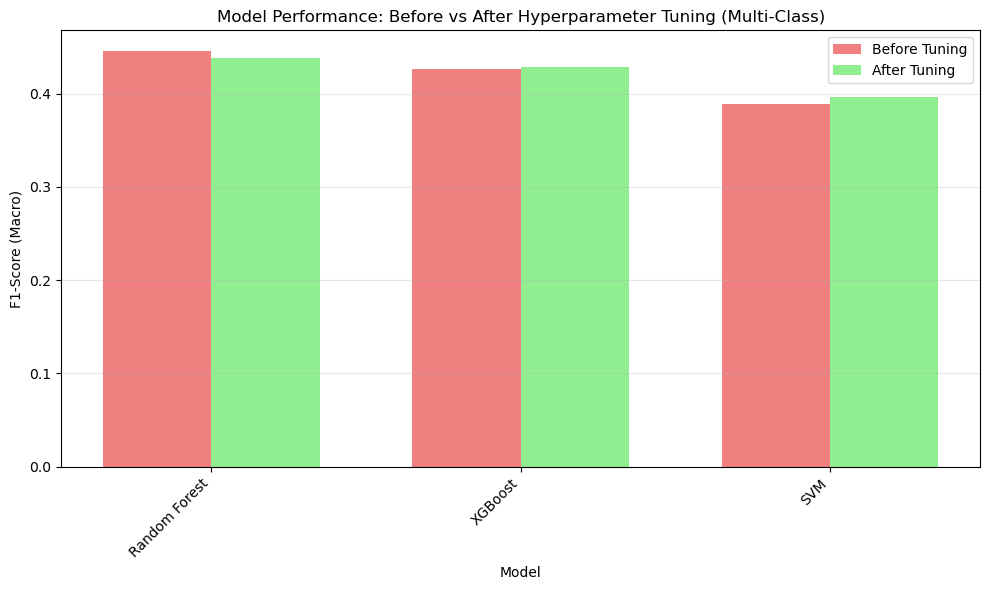

In [25]:
# =============================================================================
# STEP 5: EVALUATE TUNED MODELS ON TEST SET (MULTI-CLASS)
# =============================================================================

print("\n" + "="*70)
print("TUNED MODELS EVALUATION ON TEST SET")
print("="*70)

tuned_results = {}

for model_name, model in tuned_models.items():
    print(f"\n{model_name}:")
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Multi-class metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')  # ← Multi-class
    f1_weighted = f1_score(y_test, y_pred, average='weighted')  # ← Multi-class
    
    # Multi-class ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_scaled)
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    else:
        roc_auc = None
    
    tuned_results[model_name] = {
        'accuracy': accuracy,
        'f1_macro': f1_macro,  # ← Changed
        'f1_weighted': f1_weighted,  # ← Added
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba if hasattr(model, 'predict_proba') else None,
        'model': model
    }
    
    print(f"  Accuracy:      {accuracy:.4f}")
    print(f"  F1 (macro):    {f1_macro:.4f}")
    print(f"  F1 (weighted): {f1_weighted:.4f}")
    if roc_auc:
        print(f"  ROC-AUC:       {roc_auc:.4f}")

print("\n" + "="*70)

# Compare Before vs After Tuning
print("\nIMPROVEMENT AFTER TUNING")
print("="*70)

improvement_df = pd.DataFrame({
    'Model': list(tuned_results.keys()),
    'Before F1-Macro': [results[m]['f1_macro'] for m in tuned_results.keys()],  # ← Changed
    'After F1-Macro': [tuned_results[m]['f1_macro'] for m in tuned_results.keys()],  # ← Changed
    'Improvement': [tuned_results[m]['f1_macro'] - results[m]['f1_macro']  # ← Changed
                   for m in tuned_results.keys()]
})

print(improvement_df.to_string(index=False, float_format='%.4f'))
print("="*70)

# Visualize improvement
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(improvement_df))
width = 0.35

ax.bar(x - width/2, improvement_df['Before F1-Macro'], width, 
       label='Before Tuning', color='lightcoral')
ax.bar(x + width/2, improvement_df['After F1-Macro'], width, 
       label='After Tuning', color='lightgreen')

ax.set_xlabel('Model')
ax.set_ylabel('F1-Score (Macro)')
ax.set_title('Model Performance: Before vs After Hyperparameter Tuning (Multi-Class)')
ax.set_xticks(x)
ax.set_xticklabels(improvement_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


FINAL BEST MODEL: Random Forest

Best Hyperparameters:
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 10
  n_estimators: 200

Performance Metrics:
  Accuracy:      0.4414
  F1 (macro):    0.4380
  F1 (weighted): 0.4380
  ROC-AUC:       0.7116

Classification Report:
              precision    recall  f1-score   support

    Moderate       0.42      0.39      0.41       456
 Not Popular       0.50      0.49      0.50       457
     Popular       0.38      0.33      0.35       459
Very Popular       0.45      0.56      0.50       461

    accuracy                           0.44      1833
   macro avg       0.44      0.44      0.44      1833
weighted avg       0.44      0.44      0.44      1833



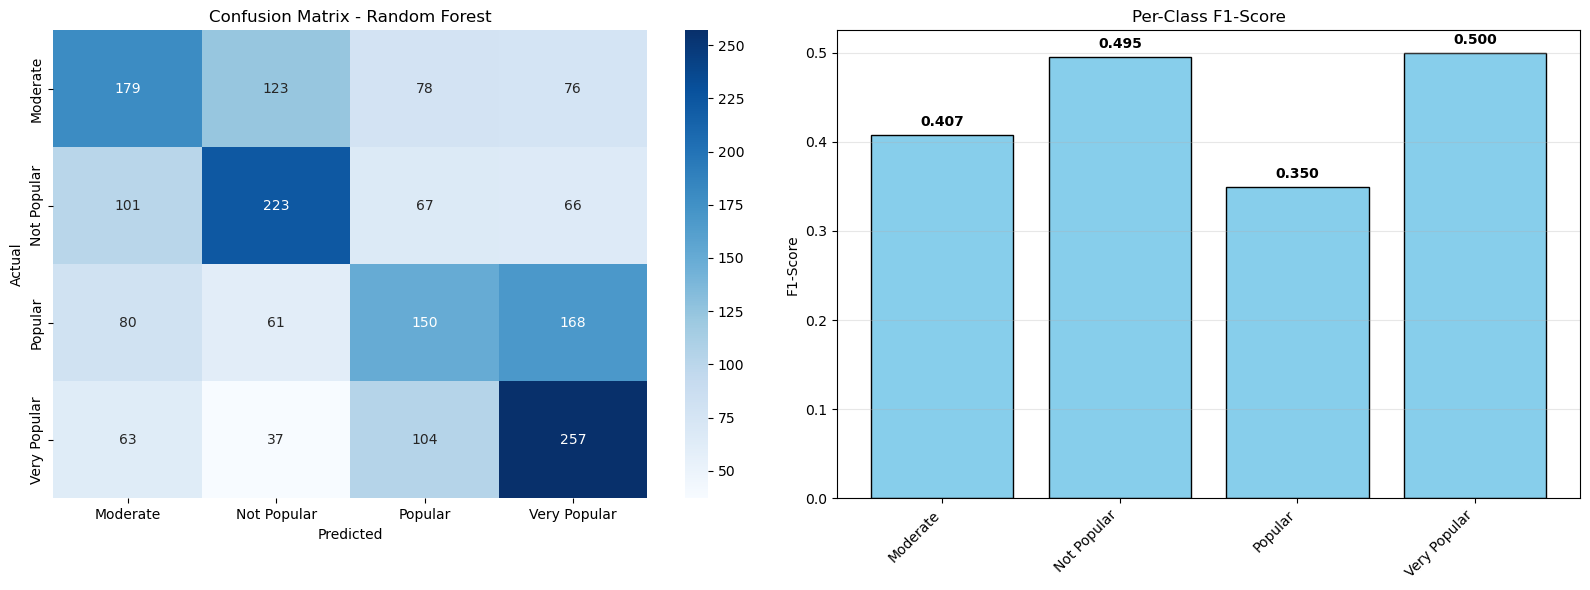

In [26]:
# =============================================================================
# FINAL BEST MODEL SELECTION AND DETAILED EVALUATION (MULTI-CLASS)
# =============================================================================

# Select best tuned model (based on F1-macro)
best_tuned_model_name = max(tuned_results.items(), key=lambda x: x[1]['f1_macro'])[0]  # ← Changed
best_tuned_model = tuned_results[best_tuned_model_name]

print("\n" + "="*70)
print(f"FINAL BEST MODEL: {best_tuned_model_name}")
print("="*70)

print("\nBest Hyperparameters:")
for param, value in tuning_results[best_tuned_model_name]['best_params'].items():
    print(f"  {param}: {value}")

print("\nPerformance Metrics:")
print(f"  Accuracy:      {best_tuned_model['accuracy']:.4f}")
print(f"  F1 (macro):    {best_tuned_model['f1_macro']:.4f}")
print(f"  F1 (weighted): {best_tuned_model['f1_weighted']:.4f}")
if best_tuned_model['roc_auc']:
    print(f"  ROC-AUC:       {best_tuned_model['roc_auc']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, best_tuned_model['predictions'],
                          target_names=label_encoder.classes_))  # ← Multi-class labels

# Final visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix (MULTI-CLASS)
cm = confusion_matrix(y_test, best_tuned_model['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,  # ← Multi-class labels
            yticklabels=label_encoder.classes_,
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_tuned_model_name}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Per-class F1 scores
report_dict = classification_report(y_test, best_tuned_model['predictions'], 
                                    target_names=label_encoder.classes_,
                                    output_dict=True)

class_f1_scores = [report_dict[label]['f1-score'] for label in label_encoder.classes_]

axes[1].bar(range(len(class_f1_scores)), class_f1_scores, 
           color='skyblue', edgecolor='black')
axes[1].set_xticks(range(len(class_f1_scores)))
axes[1].set_xticklabels(label_encoder.classes_, rotation=45, ha='right')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Per-Class F1-Score')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(class_f1_scores):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("="*70)

In [27]:
# =============================================================================
# FINAL SUMMARY: COMPLETE MODEL DEVELOPMENT PIPELINE
# =============================================================================

print("\n" + "="*70)
print("🎯 FINAL MODEL DEVELOPMENT SUMMARY")
print("="*70)

print("\n📊 DATASET")
print("-" * 70)
print(f"Total songs:        {len(df_enhanced):,}")
print(f"Training samples:   {len(y_train):,}")
print(f"Test samples:       {len(y_test):,}")
print(f"Class imbalance:    {imbalance_ratio:.2f}:1")

print("\n🔧 FEATURE ENGINEERING")
print("-" * 70)
print(f"Original features:  {len(feature_columns)}")
print(f"Selected features:  {final_feature_count}")
print(f"Reduction:          {len(feature_columns) - final_feature_count} features removed")

print("\n🏆 BEST MODEL")
print("-" * 70)
print(f"Model:              {best_tuned_model_name}")
print(f"F1-Score:           {best_tuned_model['f1_score']:.4f}")
print(f"Accuracy:           {best_tuned_model['accuracy']:.4f}")
print(f"ROC-AUC:            {best_tuned_model['roc_auc']:.4f}")

print("\n📈 PERFORMANCE IMPROVEMENTS")
print("-" * 70)
print(f"Baseline F1:        {results[best_tuned_model_name]['f1_score']:.4f}")
print(f"After Tuning:       {best_tuned_model['f1_score']:.4f}")
print(f"Total Improvement:  {best_tuned_model['f1_score'] - results[best_tuned_model_name]['f1_score']:+.4f}")

print("\n⚙️  BEST HYPERPARAMETERS")
print("-" * 70)
for param, value in tuning_results[best_tuned_model_name]['best_params'].items():
    print(f"{param:25s}: {value}")

print("\n✅ MODEL READY FOR DEPLOYMENT")
print("="*70)


🎯 FINAL MODEL DEVELOPMENT SUMMARY

📊 DATASET
----------------------------------------------------------------------
Total songs:        9,161
Training samples:   7,328
Test samples:       1,833
Class imbalance:    1.01:1

🔧 FEATURE ENGINEERING
----------------------------------------------------------------------
Original features:  15


NameError: name 'final_feature_count' is not defined